<a href="https://colab.research.google.com/github/Yasir-Aladwani/clustering-mini-project/blob/main/clustering_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<font color='87BAC3'>**Clustering Mini Project: Apply & Compare Algorithms.**</font>

## <font color='lightyellow'>**Introduction**</font>

**Clustering is an unsupervised machine learning technique used to group similar data points based on their patterns and characteristics without using labeled outputs. It helps reveal hidden structures in data and is widely used in real-world applications such as customer segmentation, health analysis, market research, and anomaly detection.**

**In this project, we apply and compare three clustering algorithms: K-Means, DBSCAN, and Hierarchical Clustering. The goal is to understand how each algorithm behaves on the selected dataset, how the clustering results differ, and which algorithm is the most suitable based on data distribution, cluster shape, noise sensitivity, and evaluation metrics.**

**The project includes data preprocessing, feature scaling, clustering implementation, visualization of results, and a final comparison.**

In [80]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [81]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [83]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [84]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X_scaled = StandardScaler().fit_transform(X)

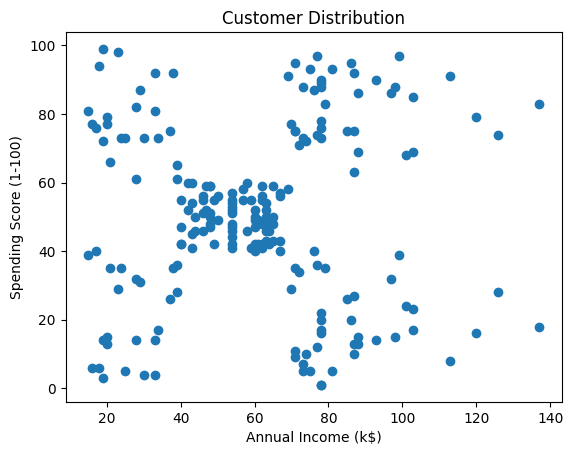

In [85]:
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.title("Customer Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

## <font color='lightyellow'>**k means algorithm**</font>

In [86]:
inertia = []
for k in range(1,10):
  model = KMeans(n_clusters = k)
  model.fit(X_scaled)
  inertia.append(model.inertia_)

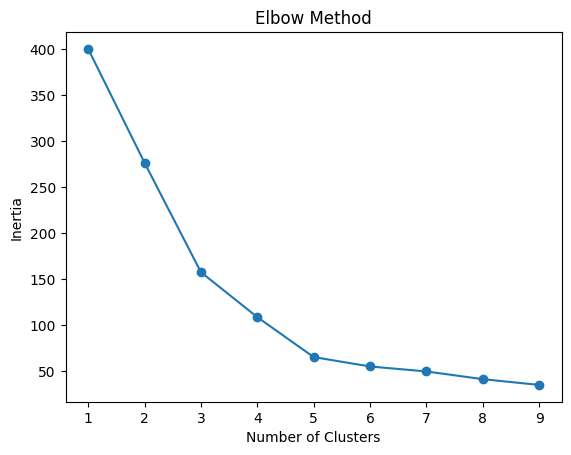

In [87]:
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## <font color='lightyellow'>**number of clusters 5**</font>

In [88]:
kmeans = KMeans(n_clusters = 5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

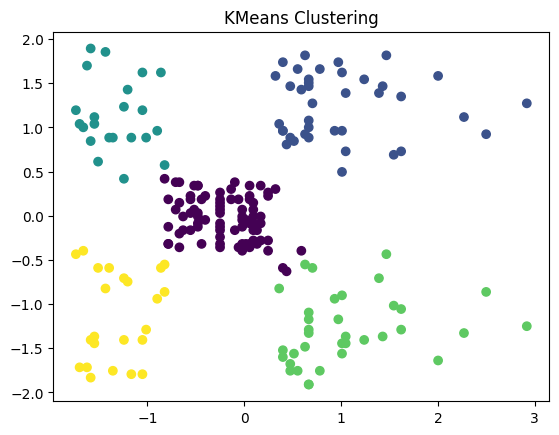

In [89]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap="viridis")
plt.title("KMeans Clustering")
plt.show()

In [90]:
score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5547


In [91]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    if len(set(labels)) > 1:  # check if more than 1 cluster
        score = silhouette_score(X_scaled, labels)
        print(f"K={k}, Silhouette={score:.4f}")

K=2, Silhouette=0.3213
K=3, Silhouette=0.4666
K=4, Silhouette=0.4939
K=5, Silhouette=0.5547
K=6, Silhouette=0.5399
K=7, Silhouette=0.5281
K=8, Silhouette=0.4552
K=9, Silhouette=0.4571


## <font color='lightyellow'>**DBSCAN algorithm**</font>

In [92]:
db = DBSCAN(eps=0.3, min_samples=3)
clusters_db = db.fit_predict(X_scaled)

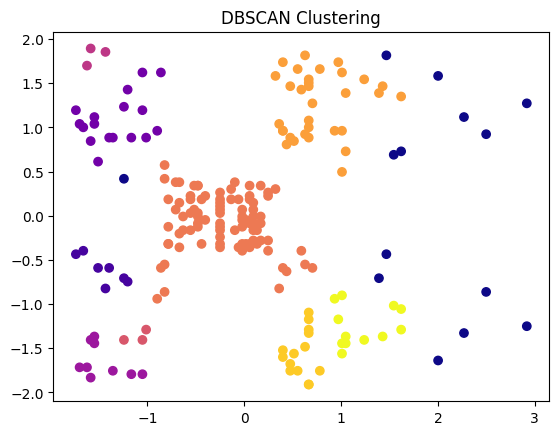

Silhouette Score: 0.4136


In [93]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_db, cmap="plasma")
plt.title("DBSCAN Clustering")
plt.show()
score = silhouette_score(X_scaled, clusters_db)
print(f"Silhouette Score: {score:.4f}")

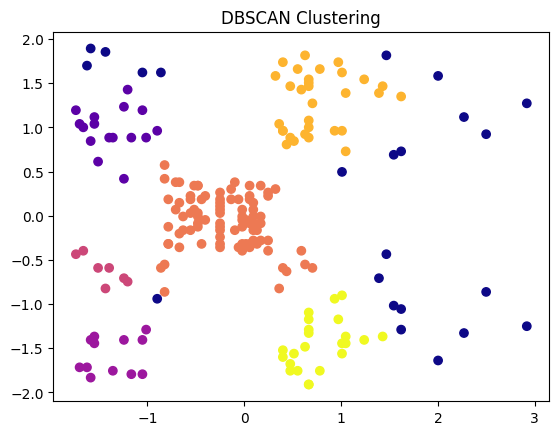

Silhouette Score: 0.4368


In [94]:
db = DBSCAN(eps=0.35, min_samples=5)
clusters_db = db.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_db, cmap="plasma")
plt.title("DBSCAN Clustering")
plt.show()
score = silhouette_score(X_scaled, clusters_db)
print(f"Silhouette Score: {score:.4f}")

## <font color='lightyellow'>**Hierarchical Clustering**</font>

In [95]:
scaler = StandardScaler()
df_stand = scaler.fit_transform(df[["Age","Annual Income (k$)","Spending Score (1-100)"]])

In [96]:
pca = PCA(n_components=2)

df_pca = pca.fit_transform(df_stand)

In [97]:
score_dict = {}

## <font color='lightyellow'>**number of clusters 3**</font>

In [98]:
hc = AgglomerativeClustering(n_clusters=3)

clusters_hc = hc.fit_predict(df_pca)

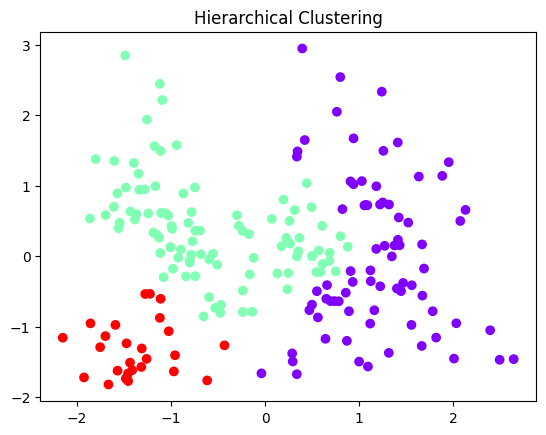

In [99]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [100]:
score_dict["HC with 3 cluster"]=silhouette_score(df_pca, clusters_hc)

## <font color='lightyellow'>**number of clusters 5**</font>

In [101]:
hc = AgglomerativeClustering(n_clusters=5)

clusters_hc = hc.fit_predict(df_pca)

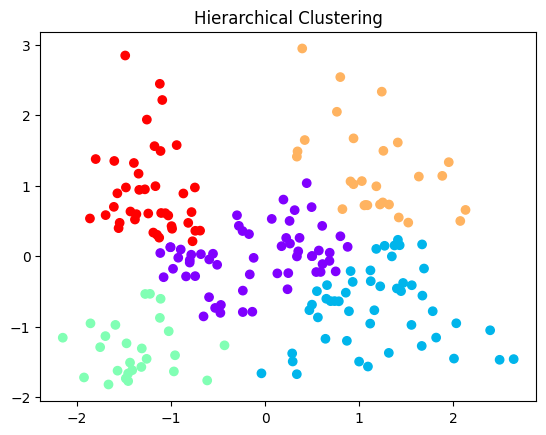

In [102]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [103]:
score_dict["HC with 5 cluster"]=silhouette_score(df_pca, clusters_hc)

<h2> Diffrenet linking method

<h3> ward

In [104]:
hc = AgglomerativeClustering(n_clusters=5,linkage="ward")

clusters_hc = hc.fit_predict(df_pca)

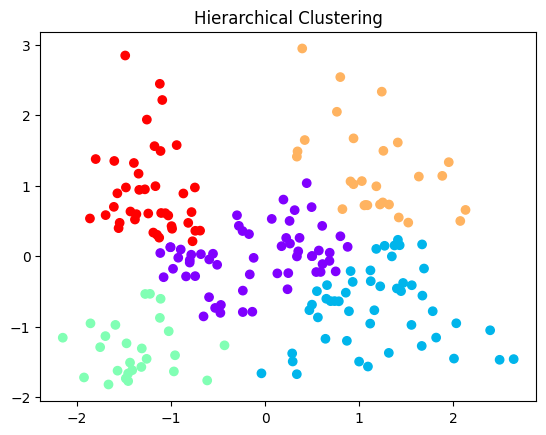

In [105]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [106]:
score_dict["HC with 5 cluster and ward linkage"]=silhouette_score(df_pca, clusters_hc)

<h3> average

In [107]:
hc = AgglomerativeClustering(n_clusters=5,linkage="average")

clusters_hc = hc.fit_predict(df_pca)

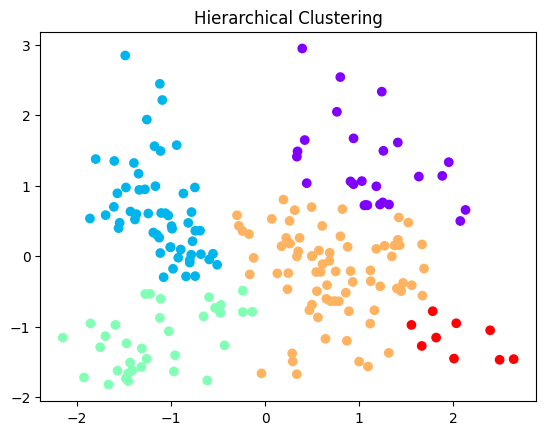

In [108]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [109]:
score_dict["HC with 5 cluster and average linkage"]=silhouette_score(df_pca, clusters_hc)

<h3>complete

In [110]:
hc = AgglomerativeClustering(n_clusters=5,linkage="complete")

clusters_hc = hc.fit_predict(df_pca)

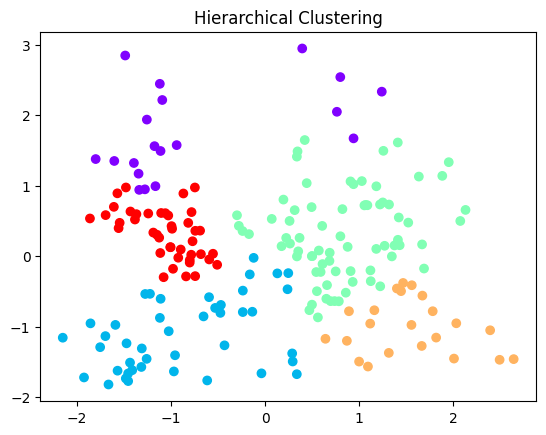

In [111]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [112]:
score_dict["HC with 5 cluster and complete linkage"]=silhouette_score(df_pca, clusters_hc)

<h3>single

In [113]:
hc = AgglomerativeClustering(n_clusters=5,linkage="single")

clusters_hc = hc.fit_predict(df_pca)

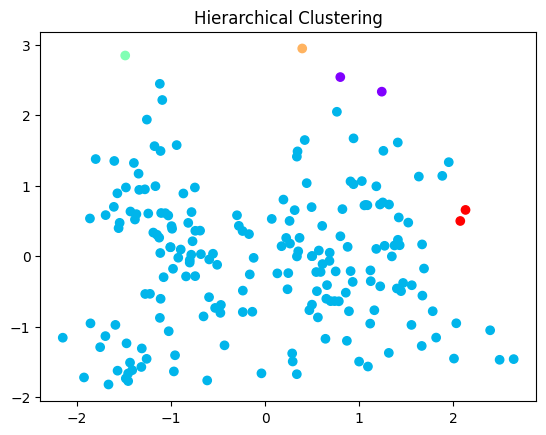

In [114]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [115]:
score_dict["HC with 5 cluster and single linkage"]=silhouette_score(df_pca, clusters_hc)

In [116]:
for method, score in score_dict.items():
    print(f"The {method} has score of {int(score*100)}%")

The HC with 3 cluster has score of 32%
The HC with 5 cluster has score of 38%
The HC with 5 cluster and ward linkage has score of 38%
The HC with 5 cluster and average linkage has score of 38%
The HC with 5 cluster and complete linkage has score of 31%
The HC with 5 cluster and single linkage has score of 7%
